# B23 — QFT and Phase Estimation in Qiskit

**Track B — the SDK.** A11 built the quantum Fourier transform out of nothing:
an $N \times N$ matrix of phases, then the same operator as a ladder of
Hadamards and controlled-phase gates, then phase estimation on top of it. This
notebook does the same three things with Qiskit's own components and checks,
entry by entry, that they are the same objects.

---

## The one-sentence version

Qiskit's `QFTGate` **is** A11's matrix — the residual is $4\times10^{-17}$, which
is float64 dust — but Qiskit's `phase_estimation()` hands back the counting
register **bit-reversed**, and if you read it the way A11 taught you, you will
get a wrong answer with no error and no warning.

## Why this notebook is mostly about bit order

Everywhere else in the repo, endianness is a *labelling* question: index 1 of a
two-qubit statevector is printed `|01>` and that is qubit 0. Annoying, learnable,
done. Here it is different, for a reason specific to the QFT.

The QFT's circuit form ends with a qubit-reversal layer (A11's Figure 4). Whether
you *need* that layer depends on which end of the register you call qubit 0, and
because the layer is pure relabelling, **a compiler is entitled to delete it and
renumber the wires instead**. So every QFT implementation in the world makes a
choice, the choice is invisible in the gate count, and getting it wrong produces
a perfectly valid unitary that computes the wrong thing. A11 drew that failure
mode as a shredded swirl. Here we meet it in a shipping library.

Qiskit makes *two* choices, and they are not the same choice:

| component | convention |
|---|---|
| `QFTGate(n)` | swaps **included** — matches A11's $F_{kj} = \omega^{jk}/\sqrt N$ exactly |
| `synth_qft_full(n, do_swaps=False)` | swaps **omitted** — equals (bit reversal) $\cdot\,F$, exactly A11's panel 2 |
| `phase_estimation(t, U)` | inverse QFT, **then an explicit reversal permutation** — the measured integer is bit-reversed |

That third row is the trap, it is in the library's own source, and it is the
thing to take away from this notebook.

## What Track A already gave us

| A11 | here |
|---|---|
| `qft_matrix(n)` — the dense $\omega^{jk}/\sqrt N$ | `Operator(QFTGate(n))` |
| `qft_circuit(n, swaps=True/False)` — H, CP, SWAP by hand | `synth_qft_full(n, do_swaps=...)` |
| `qft_circuit(n, cutoff=c)` — the approximate QFT | `synth_qft_full(n, approximation_degree=n-c)` |
| `qpe_probs(phi, t)` — QPE as explicit matrices | `phase_estimation(t, PhaseGate(2*pi*phi))` |
| the Dirichlet kernel, and the $4/\pi^2$ floor | unchanged — it is algebra, not an API |

## What we build here

1. **The diff panel.** Qiskit's QFT matrix, A11's QFT matrix, and
   $|{\cdot}-{\cdot}|$ at machine epsilon, with the residual histogram beside it
   so "machine epsilon" is a measured number rather than a claim.
2. **The swap layer in the SDK**, with `do_swaps=False` shown to be A11's
   bit-reversal composition on the nose.
3. **The approximate QFT**, with Qiskit's `approximation_degree` mapped onto
   A11's `cutoff` and asserted equal.
4. **Phase estimation**, exact phase and inexact phase, with the reversal trap
   caught in the act and then fixed.
5. **Leakage, honestly** — real `SamplerV2` shots with binomial error bars on top
   of the Dirichlet kernel, and the $4/\pi^2$ floor drawn in.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister
from qiskit.circuit.library import PhaseGate, QFTGate, phase_estimation
from qiskit.quantum_info import Operator, Statevector
from qiskit.synthesis import synth_qft_full

style.use()

SEED = backends.seed_for("B23")
rng = np.random.default_rng(SEED)

print("qiskit", qiskit.__version__, " seed", SEED)
print("float64 machine epsilon:", np.finfo(float).eps)

qiskit 2.5.1  seed 20260827
float64 machine epsilon: 2.220446049250313e-16


---

## Part 1 — is `QFTGate` the same object A11 built?

A11's definition, unchanged. With $\omega = e^{2\pi i/N}$ and $N = 2^n$,

$$F_{kj} = \frac{\omega^{jk}}{\sqrt N},
\qquad\text{i.e.}\qquad
F\,|j\rangle = \frac{1}{\sqrt N}\sum_{k} \omega^{jk}\,|k\rangle,$$

little-endian, so index $j$ is the bitstring whose **rightmost** character is
qubit 0. Qiskit's docstring for `QFTGate` writes exactly this formula. Docstrings
are not evidence, so we build both matrices and subtract them.

`Operator(gate).data` is the way to get a dense matrix out of any Qiskit
instruction — it walks the definition and multiplies it out. It is the same
object `Statevector` would evolve with, not a separate reimplementation, which is
what makes the comparison meaningful.

In [2]:
def qft_matrix(n):
    """A11's dense QFT: F_kj = exp(2 pi i j k / N) / sqrt(N). Raw NumPy."""
    N = 2 ** n
    j = np.arange(N)
    return np.exp(2j * np.pi * np.outer(j, j) / N) / np.sqrt(N)


def qiskit_qft(n):
    """The dense matrix Qiskit's QFTGate actually implements."""
    return Operator(QFTGate(n)).data


print(f"{'n':>2} {'dim':>5}   {'allclose':>8}   {'max |Qiskit - A11|':>19}   "
      f"{'/ eps':>7}")
resid_by_n = {}
for n in range(1, 8):
    A = qft_matrix(n)
    Q = qiskit_qft(n)
    d = float(np.max(np.abs(Q - A)))
    resid_by_n[n] = d
    print(f"{n:>2} {2**n:>5}   {str(np.allclose(Q, A, atol=1e-12)):>8}   "
          f"{d:>19.3e}   {d/np.finfo(float).eps:>7.2f}")

print("\nNot 'close'. The largest disagreement anywhere up to n = 7 is a few")
print("float64 rounding units - the two matrices are the same matrix.")

 n   dim   allclose    max |Qiskit - A11|     / eps
 1     2       True             1.110e-16      0.50
 2     4       True             0.000e+00      0.00
 3     8       True             7.850e-17      0.35
 4    16       True             0.000e+00      0.00
 5    32       True             3.925e-17      0.18
 6    64       True             0.000e+00      0.00
 7   128       True             1.963e-17      0.09

Not 'close'. The largest disagreement anywhere up to n = 7 is a few
float64 rounding units - the two matrices are the same matrix.


### Figure 1 — the same operator, twice, and the dust between them

Four panels and a phase wheel.

Panels 1 and 2 are the QFT at $n = 5$ coloured by **phase** — the A11 swirl —
computed two completely different ways: panel 1 from `np.exp(2j*pi*outer(j,j)/N)`,
panel 2 by asking Qiskit to multiply out `QFTGate(5)`'s gate definition. Every
entry has magnitude $1/\sqrt N$, so phase *is* the matrix; if the two conventions
disagreed anywhere, the swirls would not superimpose.

Panel 3 is $|Q - A|$ on a sequential ramp. Read the colourbar, not the picture:
the whole panel spans $0$ to about $4\times10^{-17}$. There is visible structure
in it — the residual is larger where the phase ramp turns fastest, because that
is where `exp` and the gate ladder accumulate different rounding — but the
structure lives entirely below the last bit of a double.

Panel 4 is the honest version of "machine epsilon": a histogram of all $1024$
residuals against $\varepsilon = 2.22\times10^{-16}$. Most entries are *exactly*
zero — the same float came out of both routes — and the tail stops well short of
one epsilon.

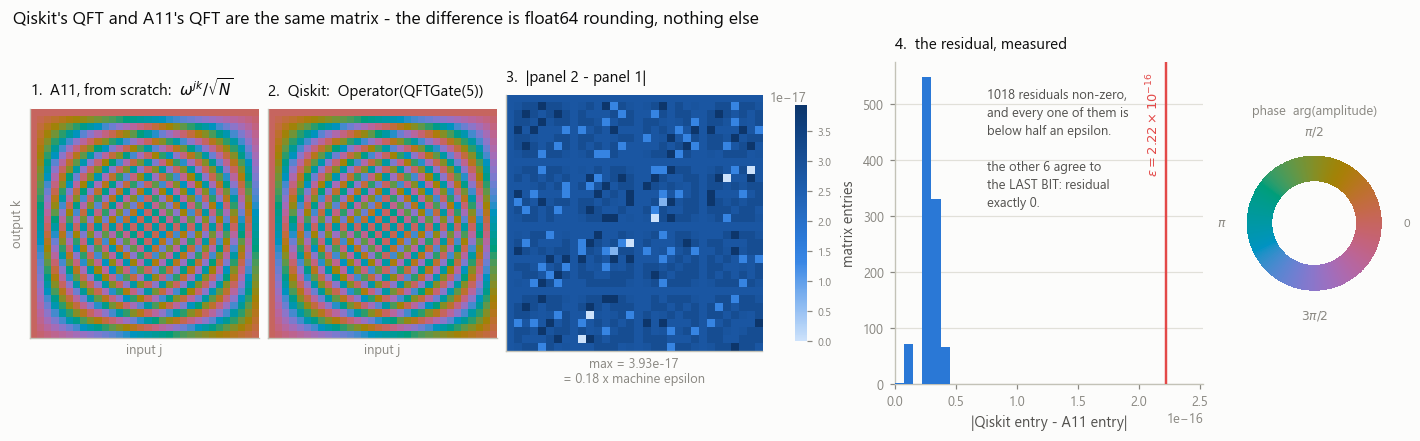

entries compared            : 1024
bit-for-bit identical       : 6
largest disagreement        : 3.925e-17  (0.18 eps)
all magnitudes 1/sqrt(32) ? : True
Qiskit's QFT is unitary     : True
Qiskit's QFT is symmetric   : True


In [3]:
NQ = 5
A5 = qft_matrix(NQ)
Q5 = qiskit_qft(NQ)
R5 = np.abs(Q5 - A5)
EPS = np.finfo(float).eps

fig = plt.figure(figsize=(12.8, 3.9))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1.12, 1.35, 0.62])

for c, (name, M) in enumerate([
        ("1.  A11, from scratch:  $\\omega^{jk}/\\sqrt{N}$", A5),
        ("2.  Qiskit:  Operator(QFTGate(5))", Q5)]):
    ax = fig.add_subplot(gs[0, c])
    grid.matrix(ax, M, part="phase", cbar=False, annot=False, title=name)
    ax.set_xlabel("input j", fontsize=8.5, color=style.MUTED)
    if c == 0:
        ax.set_ylabel("output k", fontsize=8.5, color=style.MUTED)

axd = fig.add_subplot(gs[0, 2])
im = axd.imshow(R5, cmap=style.SEQ, vmin=0, vmax=max(R5.max(), 1e-18),
                interpolation="nearest")
axd.set_xticks([])
axd.set_yticks([])
axd.grid(False)
axd.set_title("3.  |panel 2 - panel 1|", loc="left", fontsize=10)
cb = axd.figure.colorbar(im, ax=axd, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
axd.set_xlabel(f"max = {R5.max():.2e}\n= {R5.max()/EPS:.2f} x machine epsilon",
               fontsize=8.5, color=style.MUTED)

axh = fig.add_subplot(gs[0, 3])
flat = R5.ravel()
n_exact = int(np.sum(flat == 0.0))
bins = np.linspace(0, max(flat.max(), EPS) * 1.12, 34)
axh.hist(flat[flat > 0], bins=bins, color=style.BLUE, zorder=3)
axh.axvline(EPS, color=style.RED, lw=1.6, zorder=5)
axh.text(EPS * 0.985, 0.97, r"$\varepsilon = 2.22\times10^{-16}$", rotation=90,
         transform=axh.get_xaxis_transform(), ha="right", va="top",
         fontsize=8.5, color=style.RED)
axh.text(0.30, 0.92,
         f"{flat.size - n_exact} residuals non-zero,\n"
         f"and every one of them is\nbelow half an epsilon.\n\n"
         f"the other {n_exact} agree to\nthe LAST BIT: residual\nexactly 0.",
         transform=axh.transAxes, ha="left", va="top",
         fontsize=8.5, color=style.INK_2, linespacing=1.5)
axh.set_xlim(0, max(flat.max(), EPS) * 1.14)
axh.set_xlabel("|Qiskit entry - A11 entry|")
axh.set_ylabel("matrix entries")
axh.set_title("4.  the residual, measured", loc="left", fontsize=10)

axw = fig.add_subplot(gs[0, 4], projection="polar")
style.phase_wheel(axw)

fig.suptitle("Qiskit's QFT and A11's QFT are the same matrix - the difference "
             "is float64 rounding, nothing else", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print(f"entries compared            : {R5.size}")
print(f"bit-for-bit identical       : {n_exact}")
print(f"largest disagreement        : {R5.max():.3e}  "
      f"({R5.max()/EPS:.2f} eps)")
print(f"all magnitudes 1/sqrt(32) ? : "
      f"{np.allclose(np.abs(Q5), 1/np.sqrt(2**NQ))}")
print(f"Qiskit's QFT is unitary     : "
      f"{np.allclose(Q5.conj().T @ Q5, np.eye(2**NQ))}")
print(f"Qiskit's QFT is symmetric   : {np.allclose(Q5, Q5.T)}")

---

## Part 2 — the swap layer, and the flag that removes it

A11 derived the circuit form: a Hadamard on each qubit, a ladder of
controlled-phase gates $\mathrm{CP}(2\pi/2^k)$, and then $\lfloor n/2\rfloor$
SWAPs reversing the register. It also showed what happens if you skip the SWAPs —
you do not get an error, you get

$$C_{\text{no swaps}} = R \cdot F,$$

where $R$ is the bit-reversal permutation $j \mapsto \mathrm{reverse}(j)$. A
perfectly good unitary computing a different thing.

Qiskit exposes both. `QFTGate(n)` is the swapped (correct) one. The synthesis
function underneath it, **`synth_qft_full`**, takes the flag:

```python
synth_qft_full(n, do_swaps=False)
```

Note that this is where the flag lives *now*. Pre-2.0 tutorials write
`QFT(n, do_swaps=False)` — the `QFT` BlueprintCircuit class. That class still
imports in 2.5 but is deprecated in favour of `QFTGate` plus the synthesis
functions, and `QFTGate` deliberately has **no** `do_swaps` argument: a gate is
defined by the unitary it implements, and "QFT with the swaps left off" is a
different unitary, not a QFT.

So the check below is not a formality. We assert that Qiskit's swap-free
synthesis is *exactly* A11's `bit_reversal(n) @ qft_matrix(n)` — same permutation,
same direction.

In [4]:
def bit_reversal(n):
    """A11's permutation sending index j to the index with its bits reversed.

    Raw NumPy - this is the Track A object we are comparing Qiskit against.
    """
    dim = 2 ** n
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        M[int(format(i, f"0{n}b")[::-1], 2), i] = 1.0
    return M


def bitrev(m, t):
    """Reverse the t-bit binary representation of the integer m."""
    return int(format(int(m), f"0{t}b")[::-1], 2)


NS = 4
F4 = qft_matrix(NS)
qc_sw = synth_qft_full(NS, do_swaps=True)
qc_no = synth_qft_full(NS, do_swaps=False)
U_sw = Operator(qc_sw).data
U_no = Operator(qc_no).data
R4 = bit_reversal(NS)

print("synth_qft_full(4, do_swaps=True ) == A11's F            :",
      np.allclose(U_sw, F4, atol=1e-12))
print("synth_qft_full(4, do_swaps=False) == A11's R @ F        :",
      np.allclose(U_no, R4 @ F4, atol=1e-12))
print("synth_qft_full(4, do_swaps=False) == F                  :",
      np.allclose(U_no, F4, atol=1e-12), " <- the silent wrong answer")
print()
print("gate counts        with swaps:", dict(qc_sw.count_ops()))
print("                without swaps:", dict(qc_no.count_ops()))
print()
print("Both are unitary, both have every |entry| = 1/sqrt(16):")
for name, U in [("with swaps", U_sw), ("without", U_no)]:
    print(f"  {name:>11}: unitary {np.allclose(U.conj().T @ U, np.eye(16))}, "
          f"flat magnitudes {np.allclose(np.abs(U), 0.25)}")
print("\nMagnitudes cannot tell them apart. Only the phases can.")

synth_qft_full(4, do_swaps=True ) == A11's F            : True
synth_qft_full(4, do_swaps=False) == A11's R @ F        : True
synth_qft_full(4, do_swaps=False) == F                  : False  <- the silent wrong answer

gate counts        with swaps: {'cp': 6, 'h': 4, 'swap': 2}
                without swaps: {'cp': 6, 'h': 4}

Both are unitary, both have every |entry| = 1/sqrt(16):
   with swaps: unitary True, flat magnitudes True
      without: unitary True, flat magnitudes True

Magnitudes cannot tell them apart. Only the phases can.


### Figure 2 — the same failure A11 drew, in library code

Top: the circuit `synth_qft_full(4)` emits — four Hadamards, six `cp` gates with
angles $\pi, \pi/2, \pi/4, \pi/8$, and the two SWAPs at the end. That is A11's
$n(n+1)/2 = 10$ gates, gate for gate.

Bottom, left to right: A11's dense $F$; Qiskit with `do_swaps=True`; Qiskit with
`do_swaps=False`; and the residual $|U_{\text{no swaps}} - R\,F|$, which is again
at machine epsilon.

Panel 3 is the one to stare at. It is not noise and it is not obviously broken —
it is a clean, unitary, magnitude-flat operator whose phase ramps have simply
landed on the wrong rows. Nothing downstream will complain.

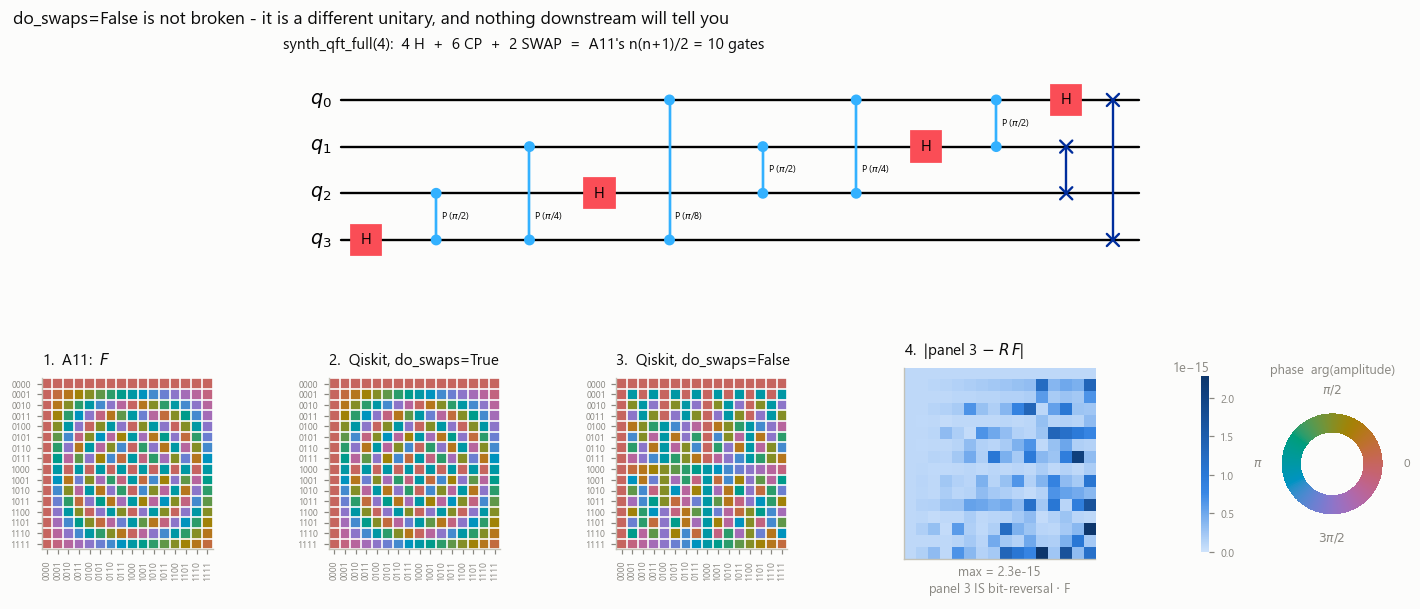

entries of the 16x16 that the missing swap layer moves: 176 of 256
angles of the cp gates, in units of pi: [0.125, 0.25, 0.5]


In [5]:
# The mpl circuit drawer fills whatever axes it is handed and sets an equal
# aspect, so a full-height panel renders the wire labels enormous. Boxing it into
# a short top row is what keeps it in proportion (the B17 trick).
fig = plt.figure(figsize=(12.8, 5.9))
gs = fig.add_gridspec(2, 5, height_ratios=[0.55, 1.0],
                      width_ratios=[1, 1, 1, 1.12, 0.62])

axc = fig.add_subplot(gs[0, :])
qc_sw.draw("mpl", ax=axc, style={"backgroundcolor": style.SURFACE},
           fold=-1)
axc.set_title("", loc="center")
axc.set_title("synth_qft_full(4):  4 H  +  6 CP  +  2 SWAP  =  A11's "
              "n(n+1)/2 = 10 gates", loc="left", fontsize=10)

panels = [("1.  A11:  $F$", F4),
          ("2.  Qiskit, do_swaps=True", U_sw),
          ("3.  Qiskit, do_swaps=False", U_no)]
for c, (name, M) in enumerate(panels):
    ax = fig.add_subplot(gs[1, c])
    grid.matrix(ax, M, part="phase", cbar=False, annot=False, title=name)

axr = fig.add_subplot(gs[1, 3])
resid = np.abs(U_no - R4 @ F4)
imr = axr.imshow(resid, cmap=style.SEQ, vmin=0, vmax=max(resid.max(), 1e-18),
                 interpolation="nearest")
axr.set_xticks([])
axr.set_yticks([])
axr.grid(False)
axr.set_title("4.  |panel 3 $-$ $R\\,F$|", loc="left", fontsize=10)
cbr = axr.figure.colorbar(imr, ax=axr, fraction=0.046, pad=0.03)
cbr.outline.set_visible(False)
cbr.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
axr.set_xlabel(f"max = {resid.max():.1e}\npanel 3 IS bit-reversal $\\cdot$ F",
               fontsize=8.5, color=style.MUTED)

axw = fig.add_subplot(gs[1, 4], projection="polar")
style.phase_wheel(axw)

fig.suptitle("do_swaps=False is not broken - it is a different unitary, and "
             "nothing downstream will tell you", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

moved = int(np.sum(~np.isclose(U_no, F4, atol=1e-12)))
print(f"entries of the 16x16 that the missing swap layer moves: {moved} of "
      f"{F4.size}")
print("angles of the cp gates, in units of pi:",
      sorted({round(float(i.operation.params[0]) / np.pi, 4)
              for i in qc_sw.data if i.operation.name == "cp"}))

---

## Part 3 — the approximate QFT, and a translation table

A11's Figure 7 made the engineering argument: the controlled-phase ladder uses
angles $2\pi/2^k$, so at $n = 20$ the smallest rotation is about $6\times10^{-6}$
radians — smaller than any real gate can be calibrated, and costing a full
two-qubit gate's worth of noise to apply something indistinguishable from the
identity. Drop them. A11 parameterised that by a **cutoff**: keep rotations with
$k \le \text{cutoff}$.

Qiskit parameterises it from the other end. `approximation_degree=d` **drops the
$d$ smallest rotations**. The two knobs run in opposite directions, which is
exactly the kind of thing that produces a silently over-approximated circuit, so
here is the translation:

$$\texttt{approximation\_degree} = n - \texttt{cutoff}.$$

We do not assert that from the docs — we build both matrices at $n = 6$ for every
$d$ and demand they agree entrywise.

The gate-count consequence is the point of the whole idea: the exact QFT needs
$\binom{n}{2}$ controlled-phase gates, $O(n^2)$; cutting at $d$ removes
$\binom{d}{2}$ of them. Take $\text{cutoff} = O(\log n)$ and you are at
$O(n\log n)$ gates with an error that fell off geometrically on the way.

In [6]:
# ---- A11's from-scratch stack, raw NumPy. No Qiskit in this cell.
I2 = np.eye(2, dtype=complex)
H_A = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
P1 = np.array([[0, 0], [0, 1]], dtype=complex)          # |1><1|


def op_on(U, k, n):
    """Place single-qubit U on qubit k. Little-endian: qubit 0 is the LAST
    Kronecker factor, so the loop runs n-1 down to 0 (A05/A06/A11's helper)."""
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def cphase_A(theta, a, b, n):
    """Controlled-phase between qubits a and b, built as I - P11 + e^{it} P11."""
    both = op_on(P1, a, n) @ op_on(P1, b, n)
    return np.eye(2 ** n, dtype=complex) - both + np.exp(1j * theta) * both


def swap_qubits(a, b, n):
    dim = 2 ** n
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        ba, bb = (i >> a) & 1, (i >> b) & 1
        j = i ^ ((ba ^ bb) << a) ^ ((ba ^ bb) << b)
        M[j, i] = 1.0
    return M


def qft_circuit_A(n, *, swaps=True, cutoff=None):
    """A11's H / CP / SWAP construction, one gate at a time."""
    M = np.eye(2 ** n, dtype=complex)
    for q in range(n - 1, -1, -1):
        M = op_on(H_A, q, n) @ M
        for m in range(q - 1, -1, -1):
            k = q - m + 1
            if cutoff is not None and k > cutoff:
                continue
            M = cphase_A(2 * np.pi / 2 ** k, m, q, n) @ M
    if swaps:
        for q in range(n // 2):
            M = swap_qubits(q, n - 1 - q, n) @ M
    return M


# ---- the translation table, checked rather than quoted
NAQ = 6
FA = qft_matrix(NAQ)
print(f"n = {NAQ}")
print(f"{'approx_degree d':>15} {'A11 cutoff n-d':>15} {'agree?':>8} "
      f"{'max |diff|':>12} {'cp gates':>9} {'max |AQFT - F|':>15}")
aq_err, aq_cp, aq_deg = [], [], list(range(NAQ))
for d in aq_deg:
    U = Operator(synth_qft_full(NAQ, approximation_degree=d)).data
    A = qft_circuit_A(NAQ, cutoff=NAQ - d)
    ncp = dict(synth_qft_full(NAQ, approximation_degree=d).count_ops()).get("cp", 0)
    err = float(np.max(np.abs(U - FA)))
    aq_err.append(err)
    aq_cp.append(ncp)
    print(f"{d:>15} {NAQ-d:>15} {str(np.allclose(U, A, atol=1e-12)):>8} "
          f"{np.max(np.abs(U - A)):>12.2e} {ncp:>9} {err:>15.3e}")

n = 6
approx_degree d  A11 cutoff n-d   agree?   max |diff|  cp gates  max |AQFT - F|
              0               6     True     4.39e-17        15       5.096e-15
              1               5     True     2.96e-17        14       1.227e-02
              2               4     True     3.47e-17        12       6.075e-02
              3               3     True     2.07e-17         9       1.852e-01
              4               2     True     0.00e+00         5       2.497e-01
              5               1     True     0.00e+00         0       2.497e-01


### Figure 3 — what the SDK actually costs

Left: gate counts straight out of `synth_qft_full(n).count_ops()` for $n$ up to
12, against A11's analytic $n(n+1)/2$. They lie on top of each other, which is
the boring and correct outcome — Qiskit is not doing anything clever, it is
emitting the textbook ladder.

Middle: the approximation error at $n = 6$ as `approximation_degree` grows, on a
log axis, with A11's hand-built AQFT matrices plotted as open markers at
$\text{cutoff} = n - d$. Same curve, computed twice.

Right: what you buy. Controlled-phase count falls as $\binom{n}{2} -
\binom{d}{2}$, and — the part that matters on hardware — the count *after*
transpiling to a real basis $\{\text{cx}, \text{rz}, \text{sx}, \text{x}\}$ falls
with it. `cp` is not a hardware gate; each one is two CX plus rotations, so the
line that a device actually pays is the orange one.

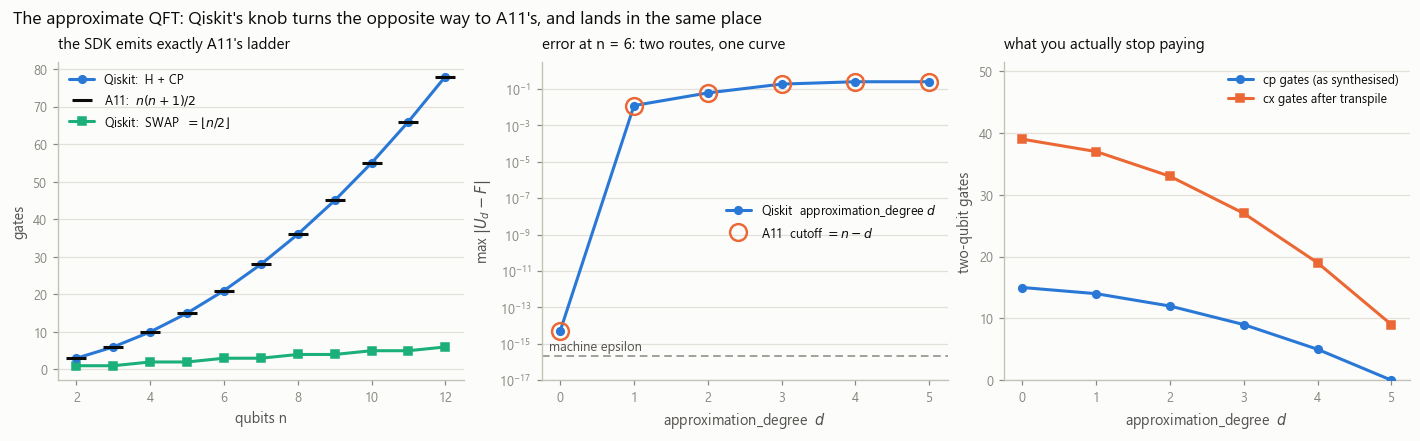

  d   cp   cx after transpile    max error
  0   15                   39    5.096e-15
  1   14                   37    1.227e-02
  2   12                   33    6.075e-02
  3    9                   27    1.852e-01
  4    5                   19    2.497e-01
  5    0                    9    2.497e-01


In [7]:
NS_GRID = list(range(2, 13))
counts = {"h": [], "cp": [], "swap": []}
for n in NS_GRID:
    ops = dict(synth_qft_full(n).count_ops())
    for k in counts:
        counts[k].append(ops.get(k, 0))
total = np.array(counts["h"]) + np.array(counts["cp"])

# Hardware cost: cp is not a basis gate anywhere. Transpile to a real basis and
# count the two-qubit gates you are actually charged for.
BASIS = ["cx", "rz", "sx", "x"]
cx_by_d = []
for d in aq_deg:
    tq = transpile(synth_qft_full(NAQ, approximation_degree=d),
                   basis_gates=BASIS, optimization_level=1,
                   seed_transpiler=SEED)
    cx_by_d.append(dict(tq.count_ops()).get("cx", 0))

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.9))

ax = axes[0]
ax.plot(NS_GRID, total, marker="o", color=style.BLUE, zorder=4,
        label="Qiskit:  H + CP")
ax.plot(NS_GRID, [n * (n + 1) // 2 for n in NS_GRID], ls="none", marker="_",
        ms=13, mew=2.0, color=style.INK, zorder=5, label="A11:  $n(n+1)/2$")
ax.plot(NS_GRID, counts["swap"], marker="s", color=style.AQUA, zorder=3,
        label=r"Qiskit:  SWAP  $= \lfloor n/2 \rfloor$")
ax.set_xlabel("qubits n")
ax.set_ylabel("gates")
ax.set_xticks(NS_GRID[::2])
ax.legend(loc="upper left", fontsize=8.2)
ax.set_title("the SDK emits exactly A11's ladder", loc="left", fontsize=10)

ax = axes[1]
ax.semilogy(aq_deg, np.maximum(aq_err, 1e-17), marker="o", color=style.BLUE,
            zorder=4, label="Qiskit  approximation_degree $d$")
hand_err = [max(np.max(np.abs(qft_circuit_A(NAQ, cutoff=NAQ - d) - FA)), 1e-17)
            for d in aq_deg]
ax.semilogy(aq_deg, hand_err, ls="none", marker="o", ms=11,
            markerfacecolor="none", markeredgecolor=style.ORANGE, mew=1.6,
            zorder=5, label="A11  cutoff $= n - d$")
ax.axhline(np.finfo(float).eps, color=style.MUTED, lw=1.0, ls=(0, (5, 3)),
           zorder=2)
ax.text(aq_deg[0] - 0.15, np.finfo(float).eps * 2.0, "machine epsilon",
        ha="left", fontsize=8.5, color=style.INK_2)
ax.set_xlabel("approximation_degree  $d$")
ax.set_ylabel(r"max $|U_d - F|$")
ax.set_xticks(aq_deg)
ax.set_ylim(1e-17, 3.0)
ax.legend(loc="center right", fontsize=8.2)
ax.set_title(f"error at n = {NAQ}: two routes, one curve", loc="left",
             fontsize=10)

ax = axes[2]
ax.plot(aq_deg, aq_cp, marker="o", color=style.BLUE, zorder=4,
        label="cp gates (as synthesised)")
ax.plot(aq_deg, cx_by_d, marker="s", color=style.ORANGE, zorder=4,
        label="cx gates after transpile")
ax.set_xlabel("approximation_degree  $d$")
ax.set_ylabel("two-qubit gates")
ax.set_xticks(aq_deg)
ax.set_ylim(0, max(cx_by_d) * 1.32)
ax.legend(loc="upper right", fontsize=8.2)
ax.set_title("what you actually stop paying", loc="left", fontsize=10)

fig.suptitle("The approximate QFT: Qiskit's knob turns the opposite way to "
             "A11's, and lands in the same place", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print(f"{'d':>3} {'cp':>4} {'cx after transpile':>20} {'max error':>12}")
for d, c, x, e in zip(aq_deg, aq_cp, cx_by_d, aq_err):
    print(f"{d:>3} {c:>4} {x:>20} {e:>12.3e}")

---

## Part 4 — phase estimation, and the trap

`phase_estimation(t, U)` returns a `QuantumCircuit` with two registers:

- `eval` — the $t$ counting qubits, which become circuit qubits $0 \ldots t-1$;
- `q` — the state register holding $|u\rangle$, at qubit $t$ and above.

It applies Hadamards to `eval`, then controlled-$U^{2^j}$ with `eval[j]` as
control, then an inverse QFT. Exactly A11's four steps.

We give it the same $U$ A11 used: $U = \mathrm{diag}(1, e^{2\pi i\varphi})$, whose
eigenstate $|u\rangle = |1\rangle$ has eigenvalue $e^{2\pi i \varphi}$. In Qiskit
that is `PhaseGate(2*pi*phi)`, and passing a **`Gate`** rather than a
`QuantumCircuit` matters twice over: Qiskit gets to use `PhaseGate`'s optimised
`.power()` and `.control()`, and — CLAUDE.md §2 — Aer refuses to execute an
anonymous controlled subcircuit (`AerError: unknown instruction: ccircuit-NNN`),
so a `QuantumCircuit` unitary would have to be transpiled before it reached a
primitive anyway.

Preparing the eigenstate is one `x` on qubit $t$. Then run it and look at where
the probability went.

In [8]:
T = 5
NT = 2 ** T


def qpe_circuit(phi, t, *, measure=False):
    """Qiskit's phase_estimation(), with |u> = |1> prepared on the target.

    U = PhaseGate(2 pi phi) = diag(1, e^{2 pi i phi}), so |1> is an eigenstate
    with eigenvalue e^{2 pi i phi}. Same U as A11's.
    """
    qpe = phase_estimation(t, PhaseGate(2 * np.pi * phi))
    qc = QuantumCircuit(qpe.num_qubits)
    qc.x(t)                                    # |u> = |1> on the state register
    qc.compose(qpe, inplace=True)
    if measure:
        qc.add_register(ClassicalRegister(t, "c"))
        qc.measure(range(t), range(t))
    return qc


def qpe_probs_qiskit(phi, t):
    """Exact P(m) over the eval register, AS QISKIT ORDERS IT.

    The state register is qubit t - the highest - so the statevector index is
    target_bit * 2**t + m and reshape(2, 2**t) splits it cleanly.
    """
    sv = Statevector(qpe_circuit(phi, t)).data
    return (np.abs(sv.reshape(2, 2 ** t)) ** 2).sum(axis=0)


def unreverse(p, t):
    """Undo phase_estimation's trailing reversal permutation: A11's index m
    lives at Qiskit's index bitrev(m)."""
    return np.asarray(p)[[bitrev(m, t) for m in range(2 ** t)]]


PHI_EXACT = 5 / 32                              # exactly representable in 5 bits
p_raw = qpe_probs_qiskit(PHI_EXACT, T)
m_raw = int(np.argmax(p_raw))

print(f"phi = 5/32 = {PHI_EXACT}, t = {T} counting qubits")
print(f"  A11 predicts m = {int(round(PHI_EXACT * NT))} "
      f"(bits {int(round(PHI_EXACT*NT)):0{T}b}) with probability 1")
print(f"  Qiskit returns m = {m_raw} (bits {m_raw:0{T}b}) with probability "
      f"{p_raw[m_raw]:.12f}")
print()
print(f"  {m_raw:0{T}b} is {int(round(PHI_EXACT*NT)):0{T}b} written backwards.")
print(f"  bitrev({int(round(PHI_EXACT*NT))}) = {bitrev(int(round(PHI_EXACT*NT)), T)}")
print()
print("  naive reading : phi = 20/32 =", 20 / 32, " <- WRONG, and off by 4x")
print("  correct       : phi = bitrev(20)/32 =", bitrev(m_raw, T) / NT)

phi = 5/32 = 0.15625, t = 5 counting qubits
  A11 predicts m = 5 (bits 00101) with probability 1
  Qiskit returns m = 20 (bits 10100) with probability 1.000000000000

  10100 is 00101 written backwards.
  bitrev(5) = 20

  naive reading : phi = 20/32 = 0.625  <- WRONG, and off by 4x
  correct       : phi = bitrev(20)/32 = 0.15625


### It is not a bug, it is in the source

The last three lines of `qiskit.circuit.library.phase_estimation` are:

```python
circuit.append(QFTGate(num_evaluation_qubits).inverse(), qr_eval[:])

reversal_pattern = list(reversed(range(num_evaluation_qubits)))
circuit.append(PermutationGate(reversal_pattern), qr_eval[:])
```

So the reversal is deliberate and explicit. Print `qc.count_ops()` and you will
see `permutation` sitting there in the open.

**What it buys.** With the permutation in place, evaluation qubit $k$ holds bit
$b_{k+1}$ of the binary fraction

$$\varphi \;\approx\; 0.b_1b_2b_3\ldots b_t \;=\; \sum_{k=1}^{t} b_k 2^{-k}.$$

Qubit 0 carries the *most significant* bit, which is a natural way to lay out an
estimate — you can truncate the register from the bottom and still have a valid
lower-precision answer.

**What it costs.** Qiskit's *printed* bitstring puts qubit $t-1$ leftmost, which
is the repo-wide little-endian convention (B17) and is not negotiable. So the
counts key reads $b_t b_{t-1}\ldots b_1$ — **the binary fraction backwards**. The
recipe is one line, and it is worth writing down where you will find it again:

```python
phi_estimate = int(counts_key[::-1], 2) / 2**t
```

**Whose fault is this?** Nobody's, and that is the uncomfortable part. Qiskit's
register order is little-endian; the binary-fraction order is big-endian by the
nature of positional notation; a QPE circuit has to pick one, and any pick makes
one of the two readings backwards. A11 picked the other way — no permutation, so
`format(m, "0tb")` reads directly as $0.b_1b_2\ldots$ — and A11's choice is
equally defensible. **The only actual error available here is failing to check
which convention you are in**, and the check costs one line: run a phase you
already know.

### Figure 4 — caught in the act

**Left**: what `phase_estimation` returns for $\varphi = 5/32$. One spike,
probability 1 (the phase is exactly representable, so there is nothing to leak),
sitting at $m = 20$. The naive reading is struck through.

**Middle**: where the crossing happens. Top row is the counts key as printed,
one character per classical bit; bottom row is the binary fraction. Every line
crosses. That picture is the whole bug.

**Right**: the same distribution after `unreverse`, with A11's from-scratch
probabilities plotted on top as markers. Spike at $m = 5$, $\varphi = 5/32$, and
the two computations agree to $10^{-12}$.

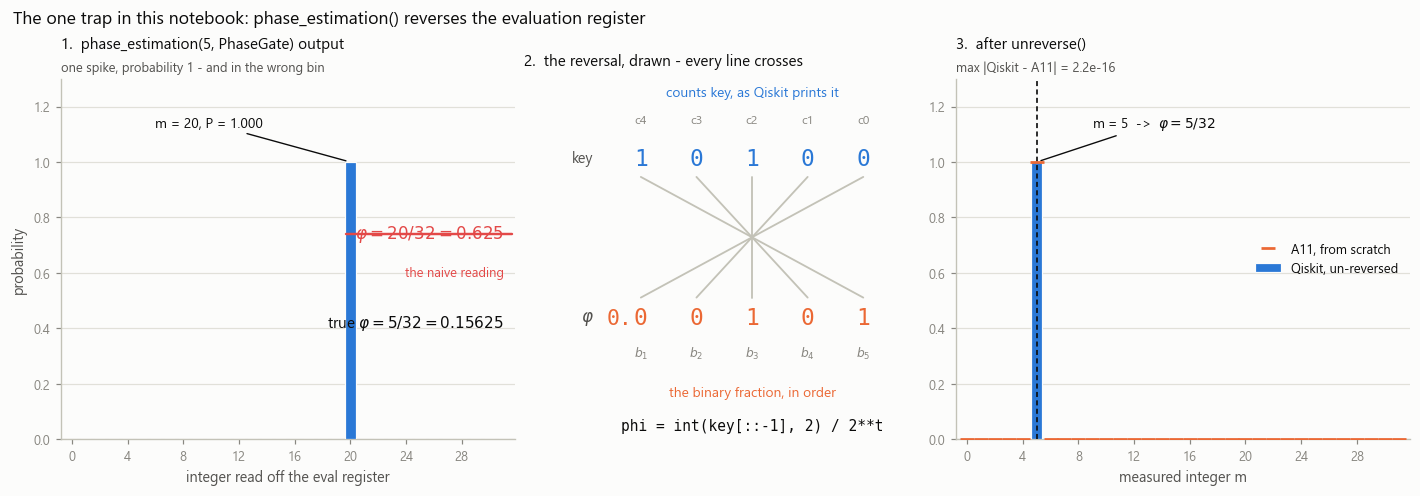

count_ops of the raw QPE circuit: {'h': 5, 'cp': 5, 'qft_dg': 1, 'permutation': 1}
  the trailing 'permutation' IS the reversal - it is not hidden.

max |Qiskit un-reversed - A11 from scratch| = 2.220e-16


In [9]:
def qpe_probs_A11(phi, t):
    """A11's phase estimation, raw NumPy, no Qiskit. Counting qubits 0..t-1,
    target qubit t. Returns P(m) in A11's (unreversed) convention."""
    n = t + 1
    N = 2 ** t
    psi = np.zeros(2 ** n, dtype=complex)
    psi[1 << t] = 1.0                       # |u> = |1> on the target
    for q in range(t):
        psi = op_on(H_A, q, n) @ psi
    for k in range(t):
        psi = cphase_A(2 * np.pi * phi * 2 ** k, k, t, n) @ psi
    psi = np.kron(I2, qft_matrix(t).conj().T) @ psi
    return (np.abs(psi.reshape(2, N)) ** 2).sum(axis=0)


p_fixed = unreverse(p_raw, T)
p_a11 = qpe_probs_A11(PHI_EXACT, T)
m_fixed = int(np.argmax(p_fixed))
key = format(m_raw, f"0{T}b")
frac = format(m_fixed, f"0{T}b")

fig = plt.figure(figsize=(12.8, 4.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 1.15])

# ---- panel A: what Qiskit hands back
axA = fig.add_subplot(gs[0, 0])
axA.bar(np.arange(NT), p_raw, width=0.8, color=style.BLUE,
        edgecolor=style.SURFACE, linewidth=0.8, zorder=3)
axA.set_xlim(-0.8, NT - 0.2)
axA.set_ylim(0, 1.30)
axA.set_xticks(np.arange(0, NT, 4))
axA.set_xlabel("integer read off the eval register")
axA.set_ylabel("probability")
bad = axA.text(NT - 1.0, 0.74, r"$\varphi = 20/32 = 0.625$", ha="right",
               va="center", fontsize=11, color=style.RED, zorder=6)
axA.text(NT - 1.0, 0.60, "the naive reading", ha="right", va="center",
         fontsize=8.5, color=style.RED, zorder=6)
axA.text(NT - 1.0, 0.42, r"true $\varphi = 5/32 = 0.15625$", ha="right",
         va="center", fontsize=10, color=style.INK, zorder=6)
grid.annotate(axA, f"m = {m_raw}, P = 1.000", xy=(m_raw, 1.0),
              xytext=(m_raw - 14.0, 1.14), color=style.INK, size=9)
axA.set_title("1.  phase_estimation(5, PhaseGate) output", loc="left",
              fontsize=10, pad=20)
axA.text(0.0, 1.012, "one spike, probability 1 - and in the wrong bin",
         transform=axA.transAxes, fontsize=8.5, color=style.INK_2, va="bottom")

# ---- panel B: the crossing
axB = fig.add_subplot(gs[0, 1])
axB.set_axis_off()
axB.set_xlim(-2.1, 5.0)
axB.set_ylim(-2.35, 1.95)
for i, ch in enumerate(key):
    axB.text(i, 1.0, ch, ha="center", va="center", fontsize=15,
             color=style.BLUE, family="monospace")
    axB.text(i, 1.46, f"c{T-1-i}", ha="center", va="center", fontsize=8,
             color=style.MUTED)
axB.text(-0.85, 1.0, "key", ha="right", va="center", fontsize=9.5,
         color=style.INK_2)
axB.text(-0.85, -0.9, r"$\varphi$", ha="right", va="center", fontsize=11,
         color=style.INK_2)
axB.text(-0.62, -0.9, "0.", ha="left", va="center", fontsize=14,
         color=style.ORANGE, family="monospace")
for j, ch in enumerate(frac):
    axB.text(j, -0.9, ch, ha="center", va="center", fontsize=15,
             color=style.ORANGE, family="monospace")
    axB.text(j, -1.32, f"$b_{{{j+1}}}$", ha="center", va="center", fontsize=8,
             color=style.MUTED)
for i in range(T):
    axB.plot([i, T - 1 - i], [0.78, -0.66], color=style.AXIS, lw=1.2,
             zorder=1)
axB.text(2.0, 1.86, "counts key, as Qiskit prints it", ha="center", va="top",
         fontsize=9, color=style.BLUE)
axB.text(2.0, -1.80, "the binary fraction, in order", ha="center", va="center",
         fontsize=9, color=style.ORANGE)
axB.text(2.0, -2.28, r"phi = int(key[::-1], 2) / 2**t", ha="center", va="bottom",
         fontsize=9.5, color=style.INK, family="monospace")
axB.set_title("2.  the reversal, drawn - every line crosses", loc="left",
              fontsize=10)

# ---- panel C: fixed, against A11
axC = fig.add_subplot(gs[0, 2])
axC.bar(np.arange(NT), p_fixed, width=0.8, color=style.BLUE,
        edgecolor=style.SURFACE, linewidth=0.8, zorder=3,
        label="Qiskit, un-reversed")
axC.plot(np.arange(NT), p_a11, ls="none", marker="_", ms=9, mew=1.8,
         color=style.ORANGE, zorder=5, label="A11, from scratch")
axC.axvline(PHI_EXACT * NT, color=style.INK, lw=1.1, ls=(0, (3, 2)), zorder=4)
axC.set_xlim(-0.8, NT - 0.2)
axC.set_ylim(0, 1.30)
axC.set_xticks(np.arange(0, NT, 4))
axC.set_xlabel("measured integer m")
axC.legend(loc="center right", fontsize=8.5)
grid.annotate(axC, f"m = {m_fixed}  ->  " + r"$\varphi = 5/32$",
              xy=(m_fixed, 1.0), xytext=(m_fixed + 4.0, 1.14),
              color=style.INK, size=9)
axC.set_title("3.  after unreverse()", loc="left", fontsize=10, pad=20)
axC.text(0.0, 1.012,
         f"max |Qiskit - A11| = {np.max(np.abs(p_fixed - p_a11)):.1e}",
         transform=axC.transAxes, fontsize=8.5, color=style.INK_2, va="bottom")

grid.strike(axA, bad)
fig.suptitle("The one trap in this notebook: phase_estimation() reverses the "
             "evaluation register", x=0.005, ha="left", fontsize=11.5)
plt.show()

print("count_ops of the raw QPE circuit:",
      dict(phase_estimation(T, PhaseGate(0.3)).count_ops()))
print("  the trailing 'permutation' IS the reversal - it is not hidden.")
print(f"\nmax |Qiskit un-reversed - A11 from scratch| = "
      f"{np.max(np.abs(p_fixed - p_a11)):.3e}")

---

## Part 5 — leakage, with real shots on top

$\varphi = 5/32$ was the flattering case. It is exactly representable in five
bits, so the geometric sum in the inverse QFT collapses to a single term and the
answer arrives with probability exactly 1. Real phases are not like that.

A11 derived the general answer. After the inverse QFT the amplitude on outcome
$m$ is a geometric sum, giving the **Dirichlet kernel**

$$P(m) = \frac{1}{N^2}\,
\frac{\sin^2\!\big(\pi N\delta_m\big)}{\sin^2\!\big(\pi \delta_m\big)},
\qquad \delta_m = \varphi - \frac{m}{N}, \quad N = 2^t.$$

That is algebra, not an API, so it is unchanged here — and it is what we plot on
top of Qiskit's exact probabilities.

What Track B adds is the third ingredient: **shots**. Every number so far came
from `Statevector`, which is a noiseless oracle no experiment has. So we also run
the circuit on `SamplerV2` — measure the eval register into an explicit
`ClassicalRegister(t, "c")`, take `result[0].data.c.get_counts()` (the register's
*name*, per CLAUDE.md §2), and un-reverse each key with `int(key[::-1], 2)`.

The error bar on each bin is the A04 binomial one, $\sqrt{p(1-p)/N_{\text{shots}}}$.
Leakage and shot noise look similar in a bar chart and are completely different
things — leakage is *structural* and does not shrink with more shots — so the
figure has to show both.

In [10]:
SHOTS = 8192
BOUND = 4 / np.pi ** 2

CASES = [
    ("exact:  " + r"$\varphi = 5/32$", 5 / 32),
    ("inexact:  " + r"$\varphi = 0.3$", 0.3),
    ("worst case:  " + r"$\varphi = 9.5/32$", 9.5 / 32),
]


def dirichlet(phi, t):
    """P(m) = sin^2(pi N d) / (N^2 sin^2(pi d)), d = phi - m/N. A11's formula."""
    N = 2 ** t
    d = phi - np.arange(N) / N
    num = np.sin(np.pi * N * d) ** 2
    den = (N * np.sin(np.pi * d)) ** 2
    return np.where(np.abs(den) < 1e-24, 1.0, num / np.where(den == 0, 1, den))


def qpe_sampled(phi, t, *, shots=SHOTS, seed=SEED):
    """SamplerV2 counts, un-reversed into A11's index convention.

    `int(key[::-1], 2)` is the whole fix: the counts key is the binary fraction
    printed backwards, so reversing the STRING gives A11's integer m directly.
    """
    qc = qpe_circuit(phi, t, measure=True)
    tqc = transpile(qc, backends.get_backend(), seed_transpiler=seed)
    res = backends.sampler(shots=shots, seed=seed).run([tqc]).result()
    counts = res[0].data.c.get_counts()          # ".c" = the register's NAME
    hits = np.zeros(2 ** t)
    for key, v in counts.items():
        hits[int(key[::-1], 2)] += v
    p = hits / hits.sum()
    return p, np.sqrt(p * (1 - p) / hits.sum())


for name, phi in CASES:
    p = unreverse(qpe_probs_qiskit(phi, T), T)
    a = dirichlet(phi, T)
    m = int(np.argmax(p))
    print(f"phi*N = {phi*NT:7.3f}   best m = {m:>2} ({m:0{T}b})   "
          f"P = {p[m]:.6f}   matches Dirichlet: "
          f"{np.allclose(p, a, atol=1e-12)}   sum = {p.sum():.10f}")

phi*N =   5.000   best m =  5 (00101)   P = 1.000000   matches Dirichlet: True   sum = 1.0000000000
phi*N =   9.600   best m = 10 (01010)   P = 0.573081   matches Dirichlet: True   sum = 1.0000000000
phi*N =   9.500   best m =  9 (01001)   P = 0.405610   matches Dirichlet: True   sum = 1.0000000000


### Figure 5 — three phases, three stories

**Left, $\varphi = 5/32$.** One bin, probability 1. The sampled bar sits on top
with a zero-width error bar, because 8192 out of 8192 shots landed in the same
place. This is the picture textbooks draw and it is the least representative one.

**Middle, $\varphi = 0.3$.** $0.3$ in binary is $0.0100110011\overline{0011}$ —
never exactly representable, at any $t$. $\varphi N = 9.6$, so the spiral does not
fit a whole number of turns into the register and the peak spills into its
neighbours. The nearest bitstring $m = 10$ still wins, but around a third of the
probability has left the building, and the skirt leans toward $9$ because $9.6$ is
nearer $10$ than $9$.

**Right, $\varphi = 9.5/32$.** $\varphi N$ exactly halfway between two integers:
the worst case there is. $9$ and $10$ split the probability evenly and each holds
about $0.405$ — the dashed grey line, $4/\pi^2$. That is the famous floor, and it
is a *floor*: the nearest bitstring is returned with probability at least
$4/\pi^2 \approx 0.4053$ whatever $\varphi$ is. At finite $N$ the true worst case
is $1/(N^2\sin^2(\pi/2N))$, marginally above it, approaching it from above as
$N \to \infty$.

The orange dashes are the Dirichlet kernel and the black points are 8192 real
shots with binomial error bars. All three agree, which is the point: the leakage
is not noise. Sample it harder and the error bars shrink around the *same*
skirt.

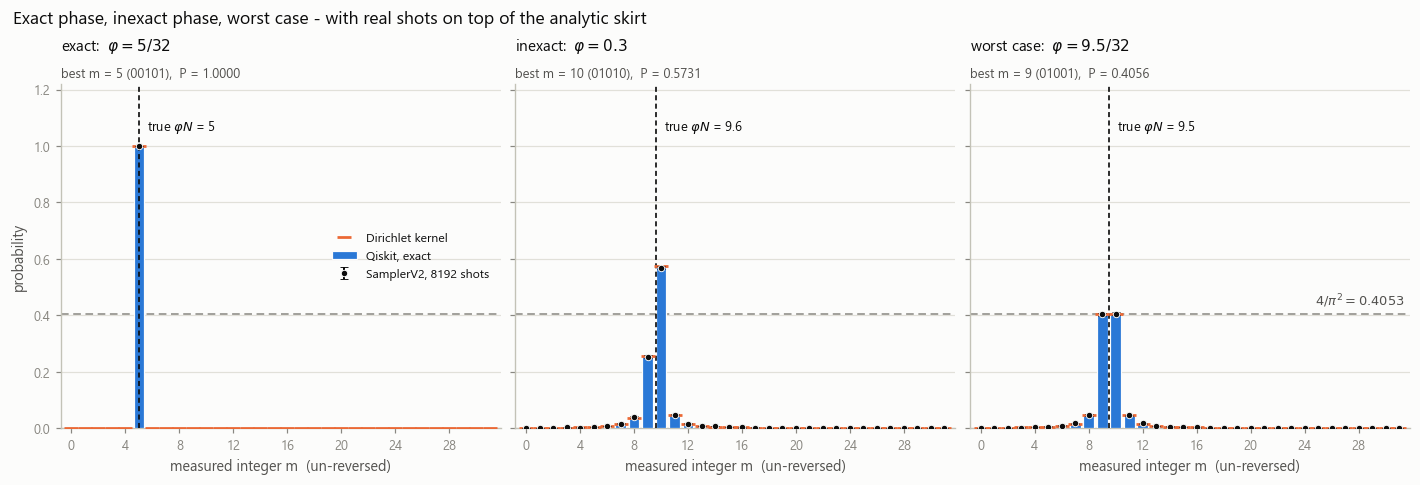

   phi*N   P(best)   P(best 2)    leaked   sampled P(best)


    5.00    1.0000      1.0000    0.0000      1.0000 +- 0.0000


    9.60    0.5731      0.8279    0.1721      0.5693 +- 0.0055


    9.50    0.4056      0.8112    0.1888      0.4036 +- 0.0054

4/pi^2 = 0.405285
finite-N worst case at N = 32: 0.405610  (above the bound)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.3), sharey=True)
idx = np.arange(NT)

for ax, (name, phi) in zip(axes, CASES):
    p = unreverse(qpe_probs_qiskit(phi, T), T)
    a = dirichlet(phi, T)
    ps, sig = qpe_sampled(phi, T)
    m = int(np.argmax(p))

    ax.bar(idx, p, width=0.8, color=style.BLUE, edgecolor=style.SURFACE,
           linewidth=0.8, zorder=3, label="Qiskit, exact")
    ax.plot(idx, a, ls="none", marker="_", ms=9, mew=1.8, color=style.ORANGE,
            zorder=5, label="Dirichlet kernel")
    keep = ps > 0.5 / SHOTS
    ax.errorbar(idx[keep], ps[keep], yerr=sig[keep], ls="none", marker="o",
                ms=4.2, color=style.INK, markeredgecolor=style.SURFACE,
                markeredgewidth=0.6, elinewidth=1.3, capsize=2.5, zorder=6,
                label=f"SamplerV2, {SHOTS} shots")
    ax.axvline(phi * NT, color=style.INK, lw=1.1, ls=(0, (3, 2)), zorder=4)
    ax.text(phi * NT + 0.6, 1.10, r"true $\varphi N$ = " + f"{phi*NT:g}",
            fontsize=8.5, color=style.INK, va="top")
    ax.axhline(BOUND, color=style.MUTED, lw=1.0, ls=(0, (5, 3)), zorder=2)

    ax.set_xlim(-0.8, NT - 0.2)
    ax.set_ylim(0, 1.22)
    ax.set_xticks(np.arange(0, NT, 4))
    ax.set_xlabel("measured integer m  (un-reversed)")
    ax.set_title(name, loc="left", fontsize=10, pad=22)
    ax.text(0.0, 1.012, f"best m = {m} ({m:0{T}b}),  P = {p[m]:.4f}",
            transform=ax.transAxes, fontsize=8.5, color=style.INK_2,
            va="bottom")

axes[0].set_ylabel("probability")
axes[0].legend(loc="center right", fontsize=8.0)
axes[2].text(NT - 0.6, BOUND + 0.03, r"$4/\pi^2 = 0.4053$", ha="right",
             fontsize=8.5, color=style.INK_2)
fig.suptitle("Exact phase, inexact phase, worst case - with real shots on top "
             "of the analytic skirt", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'phi*N':>8} {'P(best)':>9} {'P(best 2)':>11} {'leaked':>9} "
      f"{'sampled P(best)':>17}")
for name, phi in CASES:
    p = unreverse(qpe_probs_qiskit(phi, T), T)
    ps, sig = qpe_sampled(phi, T)
    o = np.argsort(-p)
    print(f"{phi*NT:>8.2f} {p[o[0]]:>9.4f} {p[o[0]]+p[o[1]]:>11.4f} "
          f"{1-p[o[0]]-p[o[1]]:>9.4f} "
          f"{ps[o[0]]:>11.4f} +- {sig[o[0]]:.4f}")
print(f"\n4/pi^2 = {BOUND:.6f}")
print(f"finite-N worst case at N = {NT}: "
      f"{1/(NT**2 * np.sin(np.pi/(2*NT))**2):.6f}  (above the bound)")

---

## Part 6 — more qubits buy precision, not certainty

Each extra evaluation qubit doubles $N$, halves the bin width $1/N$, and so buys
**one more bit of $\varphi$**. The small multiples below all show the same
$\varphi = 0.3$, plotted against $m/N$ so the horizontal axis means the same thing
in every panel. The peak stays at $0.3$ and gets narrower.

The right-hand panel is the one people get wrong. $P(\text{best } m)$ against $t$
does **not** climb. It wanders in a band above $4/\pi^2$ forever, depending on how
nearly $\varphi 2^t$ happens to land on an integer at that particular $t$. Adding
evaluation qubits makes the answer *more precise*, never *more certain*.

If you need success probability $1-\epsilon$ rather than $\sim0.4$, the fix is
repetition and a majority vote, or $O(\log 1/\epsilon)$ extra qubits whose
precision you then throw away. The honest cost of phase estimation is measured in
**runs**, and B24 pays that bill for real when it puts success rates on Shor's
order finding.

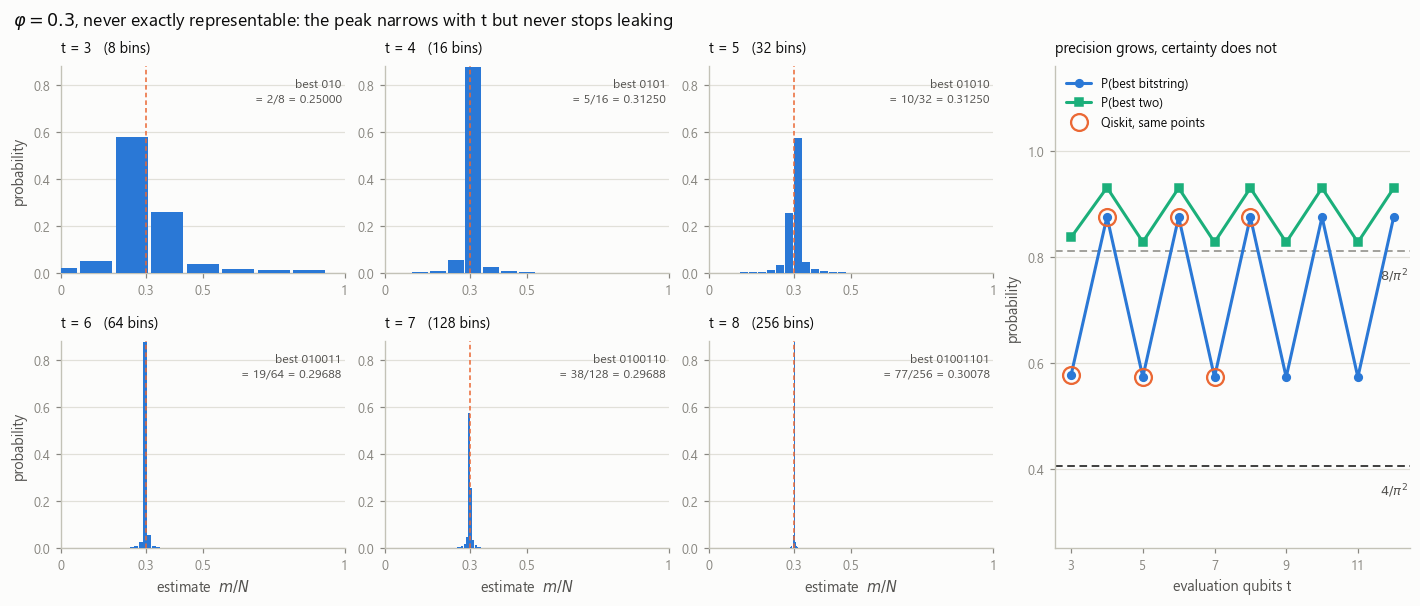

  t   bin width    best m/N    |error|   P(best)   key as printed
  3    0.125000    0.250000   0.050000    0.5775              010
  4    0.062500    0.312500   0.012500    0.8756             1010
  5    0.031250    0.312500   0.012500    0.5731            01010
  6    0.015625    0.296875   0.003125    0.8752           110010
  7    0.007812    0.296875   0.003125    0.5728          0110010
  8    0.003906    0.300781   0.000781    0.8751         10110010


In [12]:
PHI = 0.3
TS = [3, 4, 5, 6, 7, 8]

fig = plt.figure(figsize=(12.8, 5.4))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.25])

for i, t in enumerate(TS):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    N = 2 ** t
    p = unreverse(qpe_probs_qiskit(PHI, t), t)
    m = int(np.argmax(p))
    ax.bar(np.arange(N) / N, p, width=0.9 / N, color=style.BLUE, zorder=3)
    ax.axvline(PHI, color=style.ORANGE, lw=1.0, ls=(0, (3, 2)), zorder=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.88)
    ax.set_xticks([0, 0.3, 0.5, 1.0])
    ax.set_xticklabels(["0", "0.3", "0.5", "1"])
    ax.set_title(f"t = {t}   ({N} bins)", loc="left", fontsize=9.5)
    ax.text(0.99, 0.94, f"best {m:0{t}b}\n= {m}/{N} = {m/N:.5f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            color=style.INK_2)
    ax.set_ylabel("probability" if i % 3 == 0 else "")
    if i // 3:
        ax.set_xlabel(r"estimate  $m/N$")

axs = fig.add_subplot(gs[:, 3])
tt = np.arange(3, 13)
best = [np.sort(dirichlet(PHI, t))[-1] for t in tt]
top2 = [np.sort(dirichlet(PHI, t))[-2:].sum() for t in tt]
axs.plot(tt, best, marker="o", color=style.BLUE, label="P(best bitstring)")
axs.plot(tt, top2, marker="s", color=style.AQUA, label="P(best two)")
qk = [np.sort(unreverse(qpe_probs_qiskit(PHI, t), t))[-1] for t in TS]
axs.plot(TS, qk, ls="none", marker="o", ms=11, markerfacecolor="none",
         markeredgecolor=style.ORANGE, mew=1.5, zorder=5,
         label="Qiskit, same points")
axs.axhline(BOUND, color=style.INK, lw=1.0, ls=(0, (5, 3)), zorder=1)
axs.axhline(8 / np.pi ** 2, color=style.MUTED, lw=1.0, ls=(0, (5, 3)), zorder=1)
axs.text(12.4, BOUND - 0.055, r"$4/\pi^2$", ha="right", fontsize=8.5,
         color=style.INK_2)
axs.text(12.4, 8 / np.pi ** 2 - 0.055, r"$8/\pi^2$", ha="right", fontsize=8.5,
         color=style.INK_2)
axs.set_xlabel("evaluation qubits t")
axs.set_ylabel("probability")
axs.set_ylim(0.25, 1.16)
axs.set_xticks(tt[::2])
axs.legend(loc="upper left", fontsize=8.2)
axs.set_title("precision grows, certainty does not", loc="left", fontsize=9.5)

fig.suptitle(r"$\varphi = 0.3$, never exactly representable: the peak narrows "
             "with t but never stops leaking", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'t':>3} {'bin width':>11} {'best m/N':>11} {'|error|':>10} "
      f"{'P(best)':>9} {'key as printed':>16}")
for t in TS:
    N = 2 ** t
    p = unreverse(qpe_probs_qiskit(PHI, t), t)
    m = int(np.argmax(p))
    print(f"{t:>3} {1/N:>11.6f} {m/N:>11.6f} {abs(m/N - PHI):>10.6f} "
          f"{p[m]:>9.4f} {format(bitrev(m, t), f'0{t}b'):>16}")

---

## What this notebook hides

**The convention check is the deliverable, not the plots.** Everything above
reduces to one habit: *before trusting a library's QPE, feed it a phase you
already know and look at which bin lights up.* One line, five seconds, and it
catches the entire class of bug this notebook is about. We only needed six
figures because it is more convincing to see the crossing than to be told about
it.

**`Operator(...)` does not scale, and it is how we compared the matrices.**
Building a dense $2^n \times 2^n$ matrix is exponential in memory. $n = 7$ is
$128\times128$ and instant; $n = 14$ is 2 GB. Every "assert the matrix is right"
check in this notebook is therefore a *small-$n$* check, and small-$n$ agreement
does not prove large-$n$ agreement — it only proves the construction rule. That
is usually enough, because these constructions are uniform in $n$, but it is an
inference and not a measurement.

**`approximation_degree` was checked against A11, not against hardware.** We
showed the two AQFTs are the same matrix. We did not show that dropping rotations
*helps* on a real device — the claim that a noisy machine often runs the
approximate QFT *more* accurately than the exact one, because the removed gates
contributed more error than signal, is true and important and needs a noise model
to demonstrate. B26 has the machinery.

**Our $U$ was free to exponentiate.** `PhaseGate(theta).power(2**k)` is
`PhaseGate(theta * 2**k)` — one gate, any $k$. That is why this notebook's
circuits are tiny. For a real $U$ you must implement $U^{2^{t-1}}$, and unless
$U$ has special structure that is $2^{t-1}$ applications. The QFT's $O(t^2)$
gates are a rounding error next to it. Every headline "phase estimation is
efficient" silently assumes an efficient controlled-$U^{2^k}$, and finding one
*is* the algorithm-design problem. Shor's contribution was modular
exponentiation, not the QFT.

**No noise anywhere.** `Statevector` is exact and `SamplerV2` here samples an
ideal simulator, so the only randomness in Figure 5 is shot noise. On hardware, a
$t$-qubit phase estimation needs coherence across $O(2^t)$ applications of $U$,
and the controlled-phase ladder's tiny angles are exactly the gates a real
calibration cannot deliver.

**The phase wheel hides magnitude, deliberately.** Figures 1 and 2 draw only
phase. That is honest for the QFT, where every entry has magnitude $1/\sqrt N$ —
and it is precisely why `do_swaps=False` is invisible to any magnitude-based
check. Do not carry the habit to matrices where magnitude varies.

**And the QFT is still not a fast DFT for your CSV file.** A11 says it at length
and the SDK changes nothing: loading $N$ classical amplitudes is $O(N)$ work, and
a measurement returns one index sampled from $|c_k|^2$, not the spectrum. Qiskit
having a one-line `QFTGate` does not make that wall any lower.

## Checkpoint

The repo's contract: every Track B notebook closes by rebuilding the Track A
result in raw NumPy and asserting Qiskit agrees. Everything below re-derives A11
inline — dense matrix, gate ladder, bit reversal, phase estimation, Dirichlet
kernel — and demands `np.allclose` against what the SDK returned.

In [13]:
# ---- 1. THE assertion: Qiskit's QFT is A11's QFT, at every size we can build.
for n in range(1, 8):
    A = qft_matrix(n)
    Q = qiskit_qft(n)
    assert np.allclose(Q, A, atol=1e-12), n
    assert np.max(np.abs(Q - A)) < 16 * np.finfo(float).eps, n   # machine dust
    # and it really is the A11 gate ladder, not just the same dense matrix
    assert np.allclose(qft_circuit_A(n), Q, atol=1e-12), n

# ---- 2. Analytic properties of the QFT, checked on Qiskit's own matrix.
for n in range(1, 7):
    N = 2 ** n
    Q = qiskit_qft(n)
    assert np.allclose(Q.conj().T @ Q, np.eye(N), atol=1e-12)     # unitary
    assert np.allclose(Q, Q.T, atol=1e-12)                        # symmetric
    assert np.allclose(np.abs(Q), 1 / np.sqrt(N), atol=1e-12)     # flat
    assert np.allclose(np.linalg.matrix_power(Q, 4), np.eye(N), atol=1e-11)
    Q2 = np.linalg.matrix_power(Q, 2)
    for j in range(N):
        assert np.isclose(np.abs(Q2[(-j) % N, j]), 1.0, atol=1e-11)

# ---- 3. The swap flag means exactly what A11 said it means.
for n in range(2, 7):
    F = qft_matrix(n)
    U_no_swaps = Operator(synth_qft_full(n, do_swaps=False)).data
    assert np.allclose(U_no_swaps, bit_reversal(n) @ F, atol=1e-12), n
    assert np.allclose(U_no_swaps, qft_circuit_A(n, swaps=False), atol=1e-12), n
    assert not np.allclose(U_no_swaps, F)          # it is genuinely different
    assert np.allclose(U_no_swaps.conj().T @ U_no_swaps,
                       np.eye(2 ** n), atol=1e-12)  # ...and still unitary
    assert np.allclose(np.abs(U_no_swaps), 2.0 ** (-n / 2), atol=1e-12)

# ---- 4. approximation_degree = n - cutoff, entrywise, at two sizes.
for n in (4, 6):
    for d in range(n):
        U = Operator(synth_qft_full(n, approximation_degree=d)).data
        assert np.allclose(U, qft_circuit_A(n, cutoff=n - d), atol=1e-12), (n, d)
    # d = 0 is the exact QFT; error grows monotonically with d
    errs = [np.max(np.abs(Operator(synth_qft_full(n, approximation_degree=d)).data
                          - qft_matrix(n))) for d in range(n)]
    assert errs[0] < 1e-13
    assert all(errs[i] <= errs[i + 1] + 1e-15 for i in range(len(errs) - 1))

# ---- 5. Gate counts match A11's analytic n(n+1)/2 and floor(n/2).
for n in range(2, 13):
    ops = dict(synth_qft_full(n).count_ops())
    assert ops.get("h", 0) + ops.get("cp", 0) == n * (n + 1) // 2, n
    assert ops.get("swap", 0) == n // 2, n

# ---- 6. THE endianness assertion. phase_estimation's eval register is the
#         bit-reversal of A11's, for every exactly-representable phase.
for t in (3, 4, 5):
    for m_true in range(2 ** t):
        p = qpe_probs_qiskit(m_true / 2 ** t, t)
        assert np.isclose(p[bitrev(m_true, t)], 1.0, atol=1e-10), (t, m_true)
        assert np.isclose(p.sum(), 1.0, atol=1e-10)
        # ...and un-reversing lands it back where A11 put it
        assert int(np.argmax(unreverse(p, t))) == m_true

# ---- 7. Qiskit's QPE distribution == A11's from-scratch QPE, un-reversed.
for t in (3, 4, 5):
    for phi in rng.uniform(0, 1, 5):
        q = unreverse(qpe_probs_qiskit(phi, t), t)
        assert np.allclose(q, qpe_probs_A11(phi, t), atol=1e-10), (t, phi)
        assert np.allclose(q, dirichlet(phi, t), atol=1e-10), (t, phi)

# ---- 8. The 4/pi^2 floor holds against Qiskit's numbers, not just the algebra.
for t in (3, 4, 5):
    N = 2 ** t
    for phi in rng.uniform(0, 1, 12):
        q = unreverse(qpe_probs_qiskit(phi, t), t)
        assert q[int(np.round(phi * N)) % N] >= BOUND - 1e-9, (t, phi)
    worst = unreverse(qpe_probs_qiskit((np.floor(N / 3) + 0.5) / N, t), t).max()
    assert worst >= BOUND
    assert np.isclose(worst, 1 / (N ** 2 * np.sin(np.pi / (2 * N)) ** 2),
                      atol=1e-9)

# ---- 9. The counts-key recipe is the same reversal, on real shots.
p_s, sig_s = qpe_sampled(5 / 32, T)
assert np.isclose(p_s[5], 1.0)                    # exact phase -> every shot
assert np.isclose(sig_s[5], 0.0)
p_s, sig_s = qpe_sampled(0.3, T)
p_ex = unreverse(qpe_probs_qiskit(0.3, T), T)
assert int(np.argmax(p_s)) == int(np.argmax(p_ex)) == 10
assert abs(p_s[10] - p_ex[10]) < 4 * max(sig_s[10], 1e-12)

# ---- 10. Little-endian contract, restated: QFTGate on |0..0> is uniform, and
#          on |1> is a spiral advancing by exactly 2 pi / N per index.
for n in (3, 4, 5):
    N = 2 ** n
    qc0 = QuantumCircuit(n)
    qc0.append(QFTGate(n), range(n))
    assert np.allclose(Statevector(qc0).data, np.full(N, 1 / np.sqrt(N)))
    qc1 = QuantumCircuit(n)
    qc1.x(0)                                      # |1> is index 1: qubit 0 set
    qc1.append(QFTGate(n), range(n))
    out = Statevector(qc1).data
    assert np.allclose(out * np.exp(-2j * np.pi * np.arange(N) / N),
                       1 / np.sqrt(N), atol=1e-12)

print("B23 checkpoint passed.")
print(f"  max |Operator(QFTGate(n)) - A11 qft_matrix(n)|, n <= 7 : "
      f"{max(resid_by_n.values()):.3e}")
print(f"  machine epsilon                                       : "
      f"{np.finfo(float).eps:.3e}")
print(f"  QPE, phi = 5/32, t = 5: Qiskit m = {m_raw}, A11 m = {m_fixed}, "
      f"bitrev({m_raw}) = {bitrev(m_raw, T)}")

B23 checkpoint passed.
  max |Operator(QFTGate(n)) - A11 qft_matrix(n)|, n <= 7 : 1.110e-16
  machine epsilon                                       : 2.220e-16
  QPE, phi = 5/32, t = 5: Qiskit m = 20, A11 m = 5, bitrev(20) = 5


---

**Next:** [B24 — Shor's Order Finding (N = 15, 21)](B24_Shor_Order_Finding.ipynb).
Phase estimation with a $U$ you cannot exponentiate for free: modular
multiplication. B24 attaches that oracle to the front of the circuit we just
built, runs continued fractions on the back, and reports the honest success rate
over every base — which is where the $4/\pi^2$ floor and the leakage skirt stop
being decoration and start costing you runs.